In [1]:
import os
import numpy as np, pandas as pd, xarray as xr
import copernicusmarine as cm

OUTDIR = os.path.join('..', 'data', 'sla')
SITE_LON, SITE_LAT = -91.08, -1.006
BOX = dict(minimum_longitude=-92.0, maximum_longitude=-90.0,
           minimum_latitude=-2.0, maximum_latitude=0.0)
MY  = 'cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D'
NRT = 'cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D'
TODAY = pd.Timestamp.today().strftime('%Y-%m-%d')
os.makedirs(OUTDIR, exist_ok=True)

# cm.login()   # once per machine, stores your Copernicus Marine credentials

f_my = os.path.join(OUTDIR, 'duacs_my_isabela.nc')
if not os.path.exists(f_my):
    cm.subset(dataset_id=MY, variables=['sla', 'adt'], **BOX,
              start_datetime='1993-01-01', end_datetime=TODAY,
              output_directory=OUTDIR, output_filename='duacs_my_isabela.nc')
my = xr.open_dataset(f_my)
t_end = pd.Timestamp(my.time.max().values)
print('MY ends', t_end.date())

f_nrt = os.path.join(OUTDIR, 'duacs_nrt_isabela.nc')
if not os.path.exists(f_nrt):
    cm.subset(dataset_id=NRT, variables=['sla', 'adt'], **BOX,
              start_datetime=(t_end + pd.Timedelta('1D')).strftime('%Y-%m-%d'),
              end_datetime=TODAY,
              output_directory=OUTDIR, output_filename='duacs_nrt_isabela.nc')
nrt = xr.open_dataset(f_nrt)

INFO - 2026-09-21T21:46:18Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO - 2026-09-21T21:47:41Z - Selected dataset version: "202411"
INFO - 2026-09-21T21:47:41Z - Selected dataset part: "default"
WARNING - 2026-09-21T21:47:41Z - Some of your subset selection [1993-01-01 00:00:00+00:00, 2026-09-21 00:00:00+00:00] for the time dimension exceed the dataset coordinates [1993-01-01 00:00:00+00:00, 2026-01-16 00:00:00+00:00]


  0%|          | [00:00<?]

INFO - 2026-09-21T21:47:49Z - Total size of the download: 23.60 MB.
INFO - 2026-09-21T21:47:49Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


MY ends 2026-01-16


INFO - 2026-09-21T21:48:36Z - Selected dataset version: "202506"
INFO - 2026-09-21T21:48:36Z - Selected dataset part: "default"
INFO - 2026-09-21T21:48:42Z - Total size of the download: 509.58 KB.


In [2]:
# nearest cell with data on >90 % of days (skips land-masked cells near the island)
valid = (my['sla'].notnull().mean('time') > 0.9).values
LON, LAT = np.meshgrid(my.longitude.values, my.latitude.values)
d = np.hypot(LON - SITE_LON, LAT - SITE_LAT)
d[~valid] = np.inf
j, i = np.unravel_index(np.argmin(d), d.shape)
lon0, lat0 = float(my.longitude[i]), float(my.latitude[j])
print(f'using cell lon={lon0:.3f} lat={lat0:.3f} ({d[j, i]*111:.0f} km from site)')

pt_my  = my[['sla', 'adt']].sel(longitude=lon0, latitude=lat0).to_dataframe()[['sla', 'adt']]
pt_nrt = nrt[['sla', 'adt']].sel(longitude=lon0, latitude=lat0, method='nearest').to_dataframe()[['sla', 'adt']]
pt_nrt = pt_nrt[pt_nrt.index > t_end]

daily = pd.concat([pt_my, pt_nrt]).sort_index()
daily.index.name = 'time'
daily.to_csv(os.path.join(OUTDIR, 'sla_quinta_daily.csv'))
print(f'{len(daily):,} days, {daily.index.min().date()} to {daily.index.max().date()}')

using cell lon=-91.062 lat=-1.062 (7 km from site)
12,317 days, 1993-01-01 to 2026-09-21


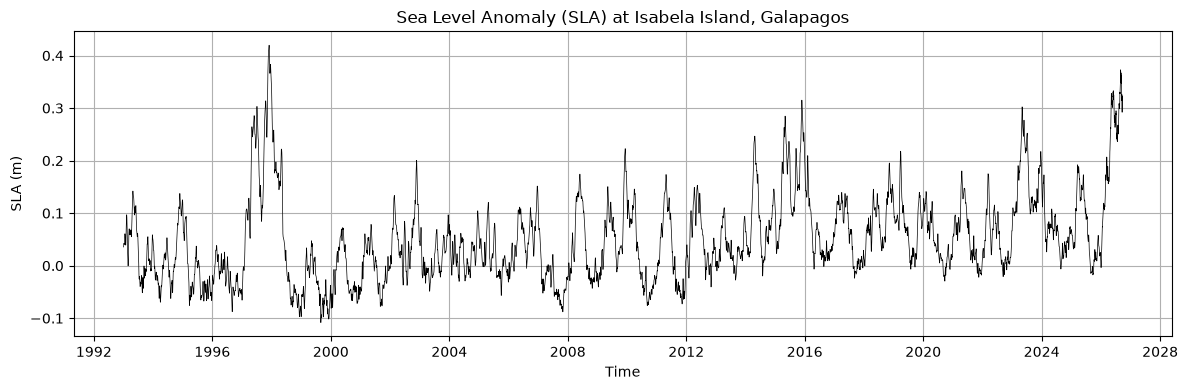

In [3]:
# Plot sla data
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily['sla'], 'k-', lw=0.5)
plt.title('Sea Level Anomaly (SLA) at Isabela Island, Galapagos')
plt.ylabel('SLA (m)')
plt.xlabel('Time')
plt.grid()
plt.tight_layout()